# **BRAIN TUMOUR DETECTION WITH CNN**

> In this project, I will implement a model that can be used to identify if a person has a brain tumour or not. I will implement a CNN model using TensorFlow, train it with a raw dataset, evaluate its performance, and visualise the results.
Link to the dataset: https://www.kaggle.com/datasets/sudipde25/mri-dataset-for-detection-and-analysis/data

## *LOADING MODULES*

> In this section, I will import the modules necessary for the project.



In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
import os

## *DATA PREPROCESSING*

> In this section, I will process the dataset assigned to me in a way that will help further implementation of the model. I will resize images to a uniform size (e.g., 150x150 pixels), normalise the pixel values, and assign numerical labels (1 for tumour, 0 for no tumour). Finally, I will split the dataset into 80% training and 20% testing.

In [36]:
def create_data_generators(directory, image_size=(150, 150), batch_size=32, validation_split=0.2):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    validation_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=validation_split
    )
    train_generator = train_datagen.flow_from_directory(
        directory,
        target_size=image_size,
        batch_size=batch_size,
        color_mode='grayscale',
        class_mode='binary',
        subset='training'
    )
    validation_generator = validation_datagen.flow_from_directory(
        directory,
        target_size=image_size,
        batch_size=batch_size,
        color_mode='grayscale',
        class_mode='binary',
        subset='validation'
    )
    return train_generator, validation_generator

In [37]:
drive.mount("/content/drive", force_remount=True)
dataset_dir = "/content/drive/My Drive/MRI_Dataset"
yes_dir = os.path.join(dataset_dir, "yes")
no_dir = os.path.join(dataset_dir, "no")
dataset_dir = "/content/drive/My Drive/MRI_Dataset"
train_generator, validation_generator = create_data_generators(dataset_dir)

Mounted at /content/drive
Found 4200 images belonging to 2 classes.
Found 1049 images belonging to 2 classes.


## *MODEL BUILDING*

> In this section, I will build my CNN model with the following parameters: an input shape of (150, 150, 3), three convolutional layers with 32, 64, and 128 filters respectively, each followed by max pooling, and a fully connected Dense layer with 512 units and ReLU activation followed by Dropout to prevent overfitting. The final output layer uses a Sigmoid activation function for binary classification. The model will be compiled using the Adam optimiser, binary cross-entropy loss, and accuracy as the evaluation metric. I will define separate classes for model building and training/evaluation for better modularity.

### MODEL CLASS

In [38]:
class BrainTumorCNN:
    @staticmethod
    def build_model(input_shape=(150, 150, 1)):
        model = Sequential()
        model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.25))
        model.add(Conv2D(64, (3, 3), activation='relu'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.25))
        model.add(Conv2D(128, (3, 3), activation='relu'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.25))
        model.add(Flatten())
        model.add(Dense(256, activation='relu'))
        model.add(Dropout(0.5))
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
        return model

### TRAINING CLASS

In [39]:
class ModelTrainer:
    def __init__(self, model, train_generator, validation_generator):
        self.model = model
        self.train_generator = train_generator
        self.validation_generator = validation_generator
        self.history = None
    def train(self, epochs=20, callbacks=None):
        self.history = self.model.fit(
            self.train_generator,
            epochs=epochs,
            validation_data=self.validation_generator,
            callbacks=callbacks
        )
        return self.history
    def plot_curve_accuracy(self):
        if not self.history:
            print("Model has not been trained yet. Please run the .train() method first.")
            return
        history_dict = self.history.history
        acc = history_dict['accuracy']
        val_acc = history_dict['val_accuracy']
        loss = history_dict['loss']
        val_loss = history_dict['val_loss']
        epochs_range = range(1, len(acc) + 1)
        plt.figure(figsize=(14, 5))
        plt.plot(epochs_range, acc, 'bo-', label='Training Accuracy')
        plt.plot(epochs_range, val_acc, 'ro-', label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        plt.show()
    def plot_curve_loss(self):
        if not self.history:
            print("Model has not been trained yet. Please run the .train() method first.")
            return
        history_dict = self.history.history
        acc = history_dict['accuracy']
        val_acc = history_dict['val_accuracy']
        loss = history_dict['loss']
        val_loss = history_dict['val_loss']
        epochs_range = range(1, len(acc) + 1)
        plt.figure(figsize=(14, 5))
        plt.plot(epochs_range, loss, 'bo-', label='Training Loss')
        plt.plot(epochs_range, val_loss, 'ro-', label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

### TESTING CLASS

In [40]:
class ModelTester:
    def __init__(self, model, test_generator):
        self.model = model
        self.test_generator = test_generator
    def evaluate(self):
        loss, accuracy = self.model.evaluate(self.test_generator, verbose=0)
        print("="*30)
        print(f"Final Test Accuracy: {accuracy * 100:.2f}%")
        print(f"Final Test Loss: {loss:.4f}")
        print("="*30)
        return loss, accuracy

## *MODEL TRAINING*

> In this section, I will display my model's architecture summary and train my model on the dataset I preprocessed before.

In [41]:
model = BrainTumorCNN.build_model(input_shape=(150, 150, 1))
print("Model Architecture Summary:")
model.summary()
trainer = ModelTrainer(
    model=model,
    train_generator=train_generator,
    validation_generator=validation_generator
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
history = trainer.train(epochs=20, callbacks=[early_stopping])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Architecture Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,033 (36.48 MB)

 Trainable params: 9,563,585 (36.48 MB)

 Non-trainable params: 448 (1.75 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 47s 299ms/step - accuracy: 0.7992 - loss: 4.2472 - val_accuracy: 0.1916 - val_loss: 6.7672
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 33s 253ms/step - accuracy: 0.8846 - loss: 0.4127 - val_accuracy: 0.8780 - val_loss: 4.7402
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 32s 245ms/step - accuracy: 0.8732 - loss: 0.4159 - val_accuracy: 0.7865 - val_loss: 1.3078
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 40s 242ms/step - accuracy: 0.8730 - loss: 0.4284 - val_accuracy: 0.7150 - val_loss: 0.9568
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 32s 241ms/step - accuracy: 0.8770 - loss: 0.4104 - val_accuracy: 0.8017 - val_loss: 0.7575
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 32s 242ms/step - accuracy: 0.8681 - loss: 0.4090 - val_accuracy: 0.8761 - val_loss: 0.4003
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 32s 245ms/step - accuracy: 0.8725 - loss: 0.4183 - val_accuracy: 0.8770 - val_loss: 0.3927
Epoch 8/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 32s 240ms/step - accuracy: 0.8772 - loss: 0

## *EVALUATION*

> In this section, I will evaluate my model using the testing dataset to obtain the final accuracy score. Then I will plot the accuracy and loss curves from the model's training history.

### ACCURACY SCORE

In [42]:
tester = ModelTester(model=model, test_generator=validation_generator)
tester.evaluate()

Final Test Accuracy: 87.70%
Final Test Loss: 0.3804


(0.38040634989738464, 0.8770257234573364)

### ACCURACY CURVES AND LOSS CURVES

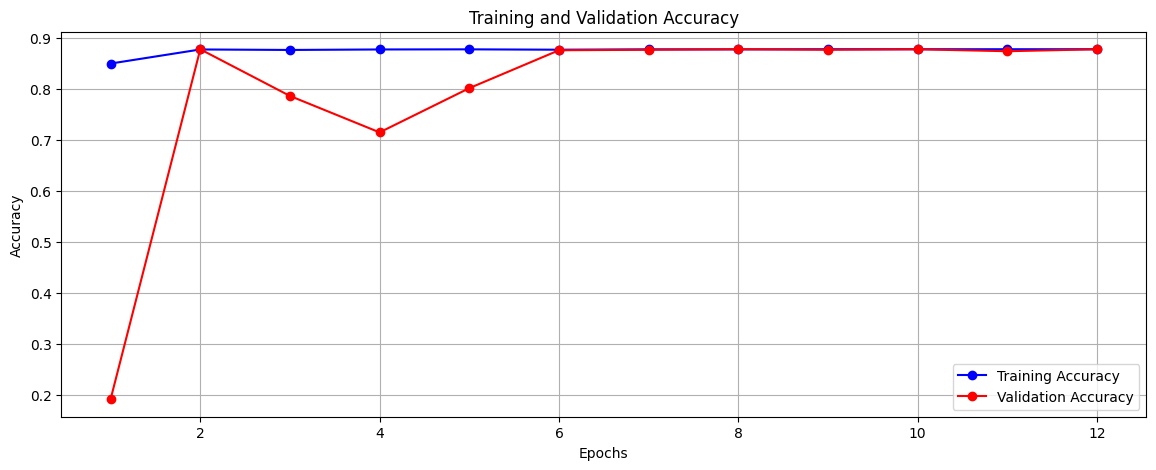

In [43]:
trainer.plot_curve_accuracy()

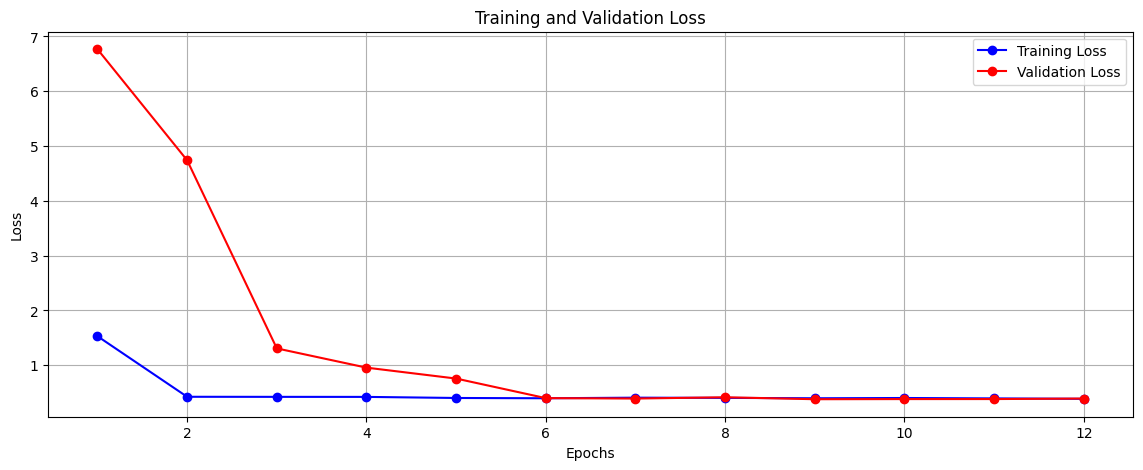

In [44]:
trainer.plot_curve_loss()